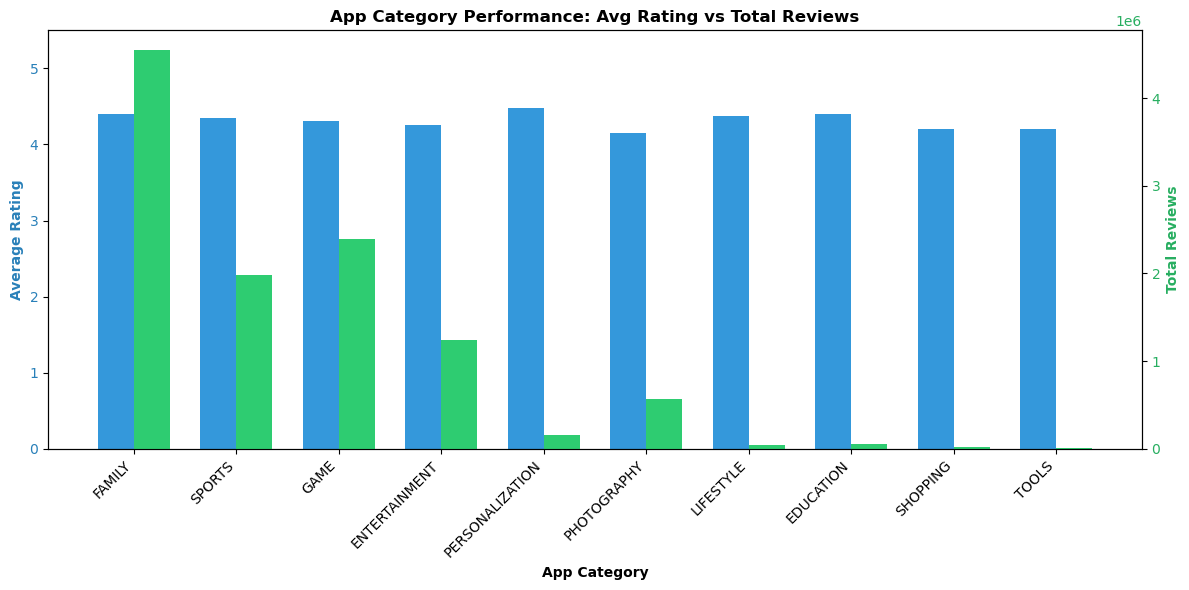

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# 1. Load the dataset (ensure 'googleplaystore.csv' is in your directory)
df = pd.read_csv('googleplaystore.csv')

# 2. Data Cleaning & Preprocessing
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Convert Size to Megabytes (ignoring 'Varies with device')
def parse_size(size_str):
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    if 'M' in size_str:
        return float(size_str.replace('M', ''))
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
    return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)

# Remove symbols from Installs and cast to numeric
df['Installs'] = df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Reviews and parse Dates
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# 3. Apply Filters
# Rating >= 4.0, Size >= 10 MB, and Last Updated in January (Month 1)
filtered_df = df[
    (df['Rating'] >= 4.0) & 
    (df['Size_MB'] >= 10.0) & 
    (df['Last Updated'].dt.month == 1)
]

# 4. Aggregation: Find the Top 10 Categories by Total Installs
top_categories = filtered_df.groupby('Category')['Installs'].sum().nlargest(10).index
top_df = filtered_df[filtered_df['Category'].isin(top_categories)]

# Group to get the metrics for our chart
final_data = top_df.groupby('Category').agg({
    'Rating': 'mean',
    'Reviews': 'sum'
}).reindex(top_categories) # Retain the install-based sorting

# 5. Time-Restricted Dashboard Display
ist_timezone = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist_timezone).time()
start_time = datetime.strptime("15:00", "%H:%M").time()
end_time = datetime.strptime("18:00", "%H:%M").time()

if start_time <= current_time <= end_time:
    # Render Grouped Bar Chart
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(final_data.index))
    width = 0.35
    
    # Left Axis: Average Rating
    ax1.bar(x - width/2, final_data['Rating'], width, color='#3498db', label='Avg Rating')
    ax1.set_xlabel('App Category', fontweight='bold')
    ax1.set_ylabel('Average Rating', color='#2980b9', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2980b9')
    ax1.set_xticks(x)
    ax1.set_xticklabels(final_data.index, rotation=45, ha='right')
    ax1.set_ylim(0, 5.5) 
    
    # Right Axis: Total Reviews
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, final_data['Reviews'], width, color='#2ecc71', label='Total Reviews')
    ax2.set_ylabel('Total Reviews', color='#27ae60', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#27ae60')
    
    plt.title('App Category Performance: Avg Rating vs Total Reviews', fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print(f"Chart hidden. Current IST Time: {current_time.strftime('%I:%M %p')}. This dashboard visualization is strictly restricted to 3:00 PM - 5:00 PM IST.")